In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [113]:
Nr = 1  #number of receptor by cell
Nd = 13   #number of days

dx = 0.025
dt = 0.0005

XX = np.linspace(0, Nr, int(Nr/dx))

k1 = 0.01 #egf influx rate
k2 = 1e-5 #egf consumption
k3 = 0.005  #egf degradation rate  ~ 4 hours

e0 = 1


k4 = 0.005 # movement to profliferative state following EGF consumption
k5 = 0.000001 # movement to quiescency due to exposure to immune cells
k6 = 0.005 # movement to quiescency

k7 = 1.45   #proliferation rate
k77 = 1      #apoptosis rate

#k8 = 0.000013      # elimination rate by immune cells

k9 = 0.01/1e7       # activation by of immune cells
a0 = 0.0
a1 = 1     

i0 = 3e7      #10^7 cells per mililiter
k10 = 0.00000005      #rate of immunosuppression

b0 = 0
b1 = 1

k11 = 0.2

def integrate_vector(c, dx):
    return np.trapz(c, dx=dx)

def act(a0, a1, dx, XX, c):
    return np.trapz(c*(a0 + a1*XX), dx=dx)




In [114]:
def simulation(k4, k5, k6, k8, k10, k7, ktreat):

    c = np.zeros([int(Nr/dx)])
    c_new = np.zeros([int(Nr/dx)])
    
    e = e0
    e_new = e0
    
    cT = np.zeros([int(Nd)])
    eT = np.zeros([int(Nd)])
    iT = np.zeros([int(Nd)])
    nT = np.zeros([int(Nd)])
    c_p_T = np.zeros([int(Nr/dx), int(Nd)])
    
    i = 0
    i_new = 0
    
    # Initial condition for c
    for ix in range(int(Nr/dx)):
        if int(0.4/dx) <= ix < int(0.6/dx):
            c[ix] = 2.5*70000000
    
    cT[0] = np.trapz(c, dx=dx)
    print(cT[0])
    eT[0] = e
    iT[0] = i
    nT[0] = np.trapz(c, dx=dx)*2e-6
    c_p_T[:, 0] = c.copy()
    
    day = 1  # day counter for indexing into cT, eT, iT
    
    for t in range(1, int(Nd/dt)):
        e_new = e + dt*(k1*(e0-e) - k2*integrate_vector(XX*c, dx)*e - k3*e)
        i_new = i + dt*(k9*act(a0, a1, dx, XX, c)*(i0-i) - k10*act(b0, b1, dx, (1-XX), c)*i - k11*i)
    
        for ix in range(1, int(Nr/dx)-1):
            c_new[ix] = (c[ix] 
                         - (dt*k4*e*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*k4*e*c[ix])
                         
                         + dt*k5*i*XX[ix]*(c[ix+1] - c[ix])/dx + dt*k5*i*c[ix]

                         - (dt*ktreat*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*ktreat*c[ix])
                         
                         + dt*k6*XX[ix]*(1-e)*(c[ix+1] - c[ix])/dx + dt*k6*(1-e)*c[ix]
                         
                         + dt*k7*XX[ix]*c[ix]
                         - dt*k8*i*XX[ix]*c[ix]
                         - dt*k77*XX[ix]*c[ix])
    
        # Boundary conditions
        #c_new[0] = c[1]
        #c_new[-1] = c[-2]
    
        e = e_new
        i = i_new
        c = c_new.copy()
    
        if t % int(1/dt) == 0:
            eT[day] = e
            cT[day] = np.trapz(c, dx=dx)
            iT[day] = i
            nT[day] = np.trapz(c, dx=dx)*2e-6
            c_p_T[:, day] = c.copy()
            day += 1
            

    return eT, cT, iT, nT, c_p_T

In [115]:
Xdata = [0, 2, 4, 6, 8, 10, 12]

# Carrier / control
Ydata1 = [56, 84, 111, 130, 159, 186, 193]

# 1639 treatment
Ydata2 = [56, 70, 89, 96, 106, 116, 132]

In [116]:
k4 = 0.01        # movement to profliferative state following EGF consumption
k5 = 0.1/1e7     # movement to quiescency due to exposure to immune cells
k6 = 0.01        #movement to quiescency due to stress
k8 = 1e-5    # elimination rate by immune cells
k10 = 1e-6      #rate of immunosuppression
k7 = 1.5         #division rate

eT, cT, iT, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0)

30625000.0


In [123]:
k4 = 0.01        # movement to profliferative state following EGF consumption
k5 = 0.1/1e7     # movement to quiescency due to exposure to immune cells
k6 = 0.01        #movement to quiescency due to stress
k8 = 1e-5    # elimination rate by immune cells
k10 = 1e-6      #rate of immunosuppression
k7 = 1.5         #division rate

eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.015)

30625000.0


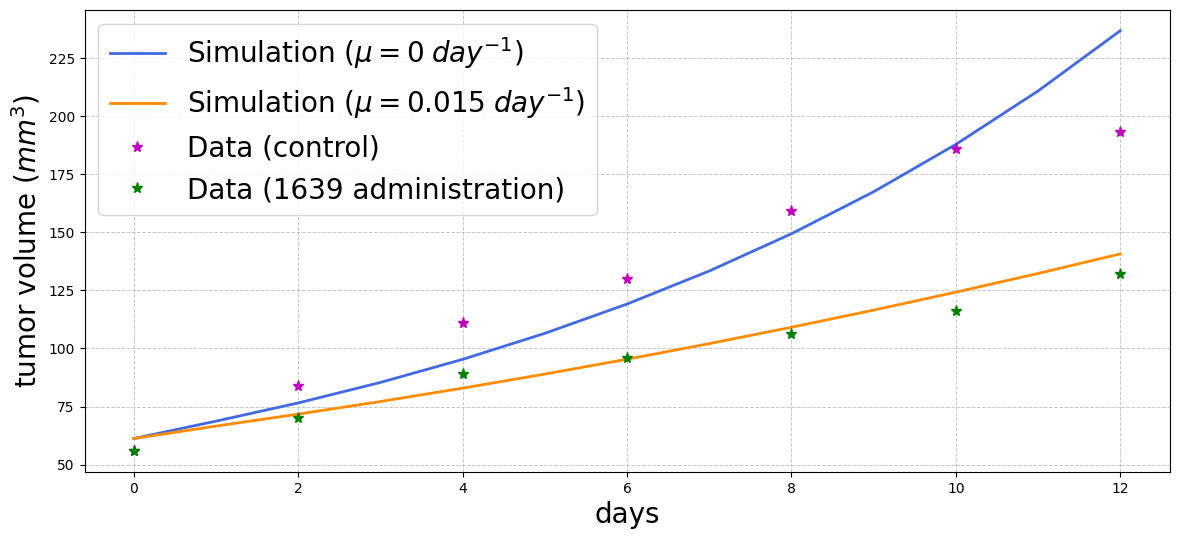

In [130]:
plt.figure(figsize=(14,6))

# Plot the simulated data with contrasting colors
plt.plot(nT, color='royalblue', linestyle='-', linewidth=2, label=r'Simulation ($\mu = 0 \; day^{-1})$')
plt.plot(nT2, color='darkorange', linestyle='-', linewidth=2, label=r'Simulation ($\mu = 0.015 \; day^{-1})$')

# Plot the observed data points
plt.plot(Xdata, Ydata1, 'm*', markersize=8, label='Data (control)')  # magenta stars
plt.plot(Xdata, Ydata2, 'g*', markersize=8, label='Data (1639 administration)')  # green stars

# Add labels and title
plt.xlabel('days', fontsize = 20)
plt.ylabel(r'tumor volume ($mm^3$)', fontsize = 20)

# Turn on grid
plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)

# Show legend
plt.legend(fontsize = 20)
plt.savefig('valid2.png')
# Display the plot
plt.show()

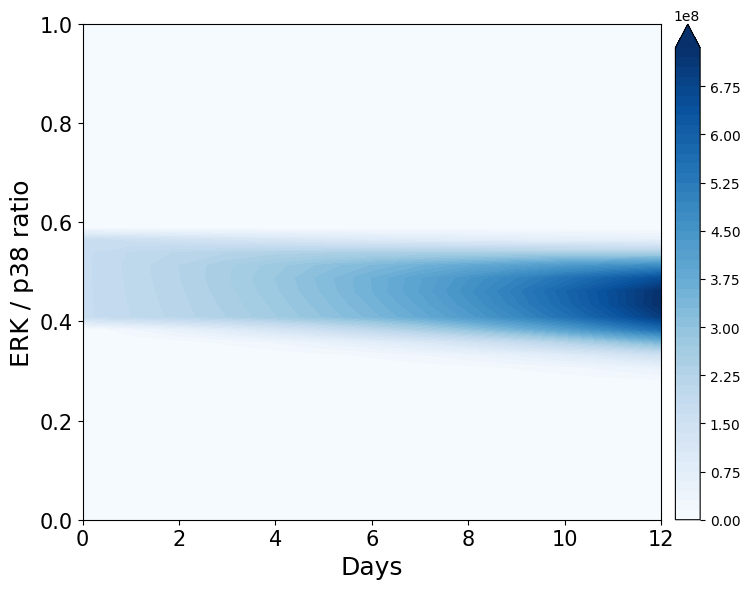

In [132]:
Y = np.linspace(0, 12, 13)
X = np.linspace(0, Nr, int(Nr/dx))


fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    Y, X, c_p_T,
    levels=60,                # smoother gradients
    cmap='Blues',             # better than viridis for intensity
    extend='max'
)

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
#cbar.set_label('Cells', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('Days', fontsize=18)
ax.set_ylabel('ERK / p38 ratio', fontsize=18)

ax.tick_params(axis='both', labelsize=15)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig('distr2-2.png')
plt.show()


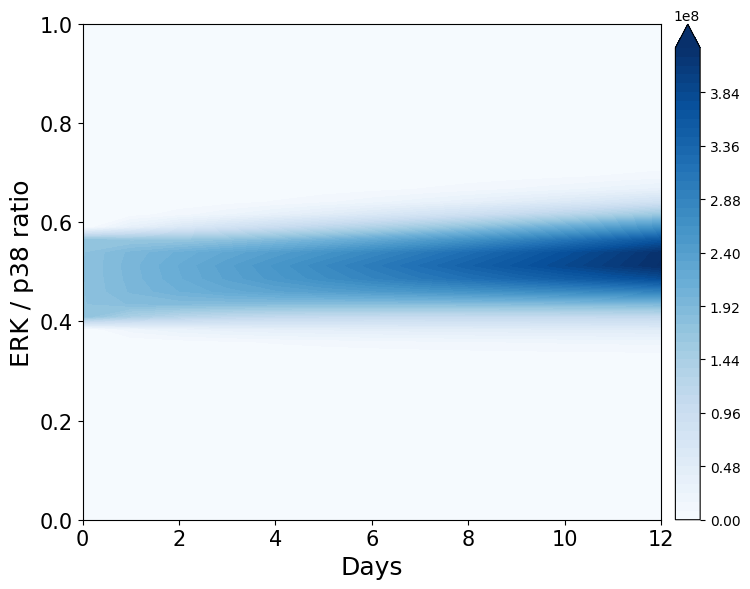

In [133]:

fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    Y, X, c_p_T2,
    levels=60,                # smoother gradients
    cmap='Blues',             # better than viridis for intensity
    extend='max'
)

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
#cbar.set_label('Cells', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('Days', fontsize=18)
ax.set_ylabel('ERK / p38 ratio', fontsize=18)

ax.tick_params(axis='both', labelsize=15)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig('distr-2.png')
plt.show()

In [129]:
import numpy as np

# Experimental data
Xdata = np.array([0, 2, 4, 6, 8, 10, 12])
Ydata1 = np.array([56, 84, 111, 130, 159, 186, 193])  # Carrier
Ydata2 = np.array([56, 70, 89, 96, 106, 116, 132])    # 1639

# Example: if your simulation time grid is called T
# T must have the same length as nT and nT2
# Example: T = np.linspace(0, 12, len(nT))

T = np.linspace(0, 12, len(nT))  # adjust if your simulation ends at another time

# Interpolate simulations at experimental time points
sim_control_at_data = np.interp(Xdata, T, nT)
sim_1639_at_data = np.interp(Xdata, T, nT2)

# Mean squared errors
mse_control = np.mean((sim_control_at_data - Ydata1)**2)
mse_1639 = np.mean((sim_1639_at_data - Ydata2)**2)

# Combined MSE
mse_total = np.mean(
    np.concatenate([
        (sim_control_at_data - Ydata1)**2,
        (sim_1639_at_data - Ydata2)**2
    ])
)

print("MSE control:", mse_control)
print("MSE 1639:", mse_1639)
print("Combined MSE:", mse_total)

MSE control: 350.23428066084847
MSE 1639: 31.406822400724113
Combined MSE: 190.82055153078628


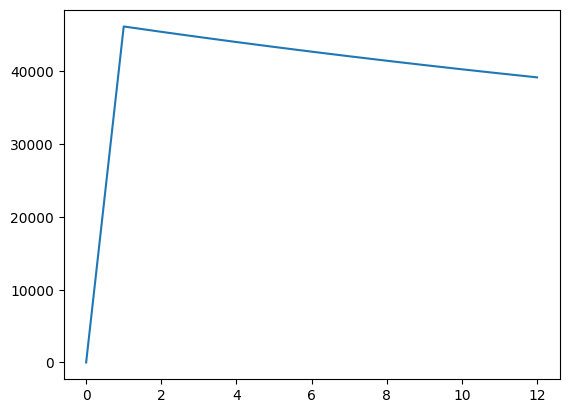

In [112]:
plt.plot(iT)31.40

In [159]:
def simulation(k4, k5, k6, k8, k10, k7, ktreat):
    XX = np.linspace(0, Nr, int(Nr/dx))
    c = np.zeros([int(Nr/dx)])
    c_new = np.zeros([int(Nr/dx)])
    
    e = e0
    e_new = e0
    
    cT = np.zeros([int(Nd)])
    eT = np.zeros([int(Nd)])
    iT = np.zeros([int(Nd)])
    nT = np.zeros([int(Nd)])
    c_p_T = np.zeros([int(Nr/dx), int(Nd)])
    
    i = 0
    i_new = 0
    
    # Initial condition for c
    mask = (XX >= 0.4) & (XX < 0.6)
    
    C0_total = 20e6  # total initial tumor volume, mm^3
    
    # Assign uniform density over the interval [0.4, 0.6]
    c[mask] = C0_total / np.sum(mask * dx)
    
    cT[0] = np.trapz(c, dx=dx)
    print(cT[0])
    eT[0] = e
    iT[0] = i
    nT[0] = np.trapz(c, dx=dx)*2e-6
    c_p_T[:, 0] = c.copy()
    
    day = 1  # day counter for indexing into cT, eT, iT
    
    for t in range(1, int(Nd/dt)):
        e_new = e + dt*(k1*(e0-e) - k2*integrate_vector(XX*c, dx)*e - k3*e)
        i_new = i + dt*(k9*act(a0, a1, dx, XX, c)*(i0-i) - k10*act(b0, b1, dx, (1-XX), c)*i - k11*i)
    
        for ix in range(1, int(Nr/dx)-1):
            c_new[ix] = (c[ix] 
                         - (dt*k4*e*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*k4*e*c[ix])
                         
                         + dt*k5*i*XX[ix]*(c[ix+1] - c[ix])/dx + dt*k5*i*c[ix]

                         - (dt*ktreat*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*ktreat*c[ix])
                         
                         + dt*k6*XX[ix]*(1-e)*(c[ix+1] - c[ix])/dx + dt*k6*(1-e)*c[ix]
                         
                         + dt*k7*XX[ix]*c[ix]
                         - dt*k8*i*XX[ix]*c[ix]
                         - dt*k77*XX[ix]*c[ix])
    
        # Boundary conditions
        #c_new[0] = c[1]
        #c_new[-1] = c[-2]
    
        e = e_new
        i = i_new
        c = c_new.copy()
    
        if t % int(1/dt) == 0:
            eT[day] = e
            cT[day] = np.trapz(c, dx=dx)
            iT[day] = i
            nT[day] = np.trapz(c, dx=dx)*2e-6
            c_p_T[:, day] = c.copy()
            day += 1
            

    return XX, eT, cT, iT, nT, c_p_T

In [172]:
dx = 0.05
dt = 0.0005
XX0, eT2, cT2, iT2, nT0, c_p_T0 = simulation(k4, k5, k6, k8, k10, k7, 0.015)


dx = 0.025
dt = 0.0005

XX, eT2, cT2, iT2, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0.015)

dx = 0.0125
dt = 0.0005
XX2, eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.015)


20000000.0
20000000.0
20000000.0


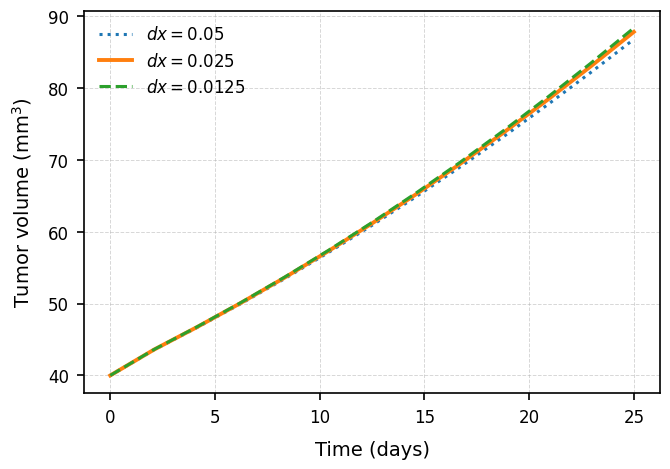

In [176]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
nT0 = np.asarray(nT0, dtype=float)
nT  = np.asarray(nT, dtype=float)
nT2 = np.asarray(nT2, dtype=float)

# Define time vectors
# Replace dt_plot by your actual temporal resolution if needed
t0 = np.linspace(0, 25, len(nT0))
t1 = np.linspace(0, 25, len(nT))
t2 = np.linspace(0, 25, len(nT2))

fig, ax = plt.subplots(figsize=(6.8, 4.8))

ax.plot(
    t0, nT0,
    linewidth=2.2,
    linestyle=":",
    label=r"$dx = 0.05$"
)

ax.plot(
    t1, nT,
    linewidth=2.8,
    linestyle="-",
    label=r"$dx = 0.025$"
)

ax.plot(
    t2, nT2,
    linewidth=2.2,
    linestyle="--",
    label=r"$dx = 0.0125$"
)

ax.set_xlabel("Time (days)", fontsize=14, labelpad=10)
ax.set_ylabel(r"Tumor volume (mm$^3$)", fontsize=14, labelpad=10)

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    width=1.2,
    length=5,
    pad=6
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.legend(
    fontsize=12,
    frameon=False,
    loc="best"
)

fig.tight_layout()

plt.savefig("grid_consistency_publication.png", dpi=600, bbox_inches="tight")
plt.savefig("grid_consistency_publication.pdf", bbox_inches="tight")

plt.show()

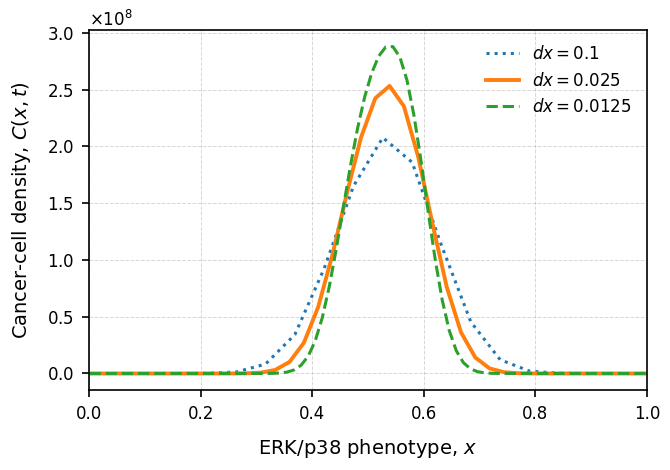

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

XX0 = np.asarray(XX0, dtype=float)
XX  = np.asarray(XX, dtype=float)
XX2 = np.asarray(XX2, dtype=float)

profile_dx_01   = np.asarray(c_p_T0[:, 12], dtype=float)
profile_dx_0025 = np.asarray(c_p_T[:, 12], dtype=float)
profile_dx_00125 = np.asarray(c_p_T2[:, 12], dtype=float)

fig, ax = plt.subplots(figsize=(6.8, 4.8))

ax.plot(
    XX0,
    profile_dx_01,
    linewidth=2.2,
    linestyle=":",
    label=r"$dx = 0.1$"
)

ax.plot(
    XX,
    profile_dx_0025,
    linewidth=2.8,
    linestyle="-",
    label=r"$dx = 0.025$"
)

ax.plot(
    XX2,
    profile_dx_00125,
    linewidth=2.2,
    linestyle="--",
    label=r"$dx = 0.0125$"
)

ax.set_xlabel(r"ERK/p38 phenotype, $x$", fontsize=14, labelpad=10)
ax.set_ylabel(r"Cancer-cell density, $C(x,t)$", fontsize=14, labelpad=10)

ax.set_xlim(0, 1)

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    width=1.2,
    length=5,
    pad=6
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(12)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.legend(
    fontsize=12,
    frameon=False,
    loc="best"
)

fig.tight_layout()

plt.savefig("phenotype_grid_consistency_day12.png", dpi=600, bbox_inches="tight")
plt.savefig("phenotype_grid_consistency_day12.pdf", bbox_inches="tight")

plt.show()